In [ ]:
import sys, os, importlib
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.cluster import KMeans

# ─── 1. ORTAM HAZIRLIĞI ──────────────────────────────────────────────────────
project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path: sys.path.insert(0, project_root)

import src.data_loader as loader
import src.utils as utils
import src.filters as f_lib
importlib.reload(loader); importlib.reload(utils); importlib.reload(f_lib)

FEATURE_COLS = [
    'GHI_Filtered', 'Solar Zenith Angle', 'Temperature', 'Relative Humidity',
    'Wind Speed', 'Cloud Type', 'Clearness_Index',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]
TARGET_COL  = 'GHI_Filtered'
LOOK_BACK   = 96
LOOK_FORWARD = 24

# ─── 2. VERİ ÇEKME ───────────────────────────────────────────────────────────
print("OOD verileri çekiliyor...")
ood_df = loader.fetch_global_ood_data(start_date="2023-01-01", end_date="2023-03-31")

# ─── 3. ZAMAN ÇÖZÜNÜRLÜĞÜ: 1 saat → 30 dakika ───────────────────────────────
# Model 30dk veriyle eğitildi; saatlik OOD verisini resample ediyoruz.
print("1 saatlik veri → 30 dakikaya resample ediliyor...")
ood_resampled = []
for city in ood_df['City'].unique():
    cdf = ood_df[ood_df['City'] == city].copy()
    cdf = cdf.set_index('datetime')
    # object dtype sütunları önceden düşür (interpolasyon uyarısını önle)
    cdf = cdf.select_dtypes(include=[np.number]).resample('30min').interpolate(method='time')
    # Döngüsel özellikler interpolasyondan sonra yeniden hesaplanmalı
    hour        = cdf.index.hour + cdf.index.minute / 60
    month       = cdf.index.month
    cdf['hour_sin']  = np.sin(2 * np.pi * hour  / 24.0)
    cdf['hour_cos']  = np.cos(2 * np.pi * hour  / 24.0)
    cdf['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    cdf['month_cos'] = np.cos(2 * np.pi * month / 12.0)
    cdf['City']      = city
    ood_resampled.append(cdf.reset_index())

ood_df = pd.concat(ood_resampled, ignore_index=True)
print(f"  Resample sonrası: {len(ood_df)} satır")

# ─── 4. REJİM ETİKETLEME ─────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
ood_df['cluster'] = kmeans.fit_predict(ood_df[FEATURE_COLS])

def get_label(row):
    if   row['GHI_Filtered'] > 400: return "Gunesli"
    elif row['GHI_Filtered'] < 100: return "Kapali"
    else:                            return "Kaotik"

ood_df['label'] = ood_df.apply(get_label, axis=1)

# ─── 5. SİNYAL FİLTRELEME ────────────────────────────────────────────────────
print("Wavelet/SavGol filtreleme uygulanıyor...")
processed = []
for city in ood_df['City'].unique():
    cdf = ood_df[ood_df['City'] == city].copy()
    for label in cdf['label'].unique():
        mask   = cdf['label'] == label
        signal = cdf.loc[mask, 'GHI_Filtered'].values.astype(float)
        cdf.loc[mask, 'GHI_Filtered'] = f_lib.apply_filter_by_label(signal, label)
    processed.append(cdf)

ood_df = pd.concat(processed, ignore_index=True)

# ─── 6. NORMALIZASYON YOK — EĞİTİMLE AYNI ───────────────────────────────────
# Eğitim pipeline'ında (04_model_training) normalizasyon yapılmadı.
# Model ham W/m² değerleriyle eğitildi → OOD'da da ham veri kullanıyoruz.
# Sadece X girdisi normalize — eğitimde de öyle mi? Hayır. Hiç normalize yok.
print("Sliding window oluşturuluyor (ham veri, eğitimle aynı pipeline)...")
test_datasets = {}
for city in ood_df['City'].unique():
    cdf  = ood_df[ood_df['City'] == city]
    X, y = utils.create_sliding_features(
        cdf,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
        look_back=LOOK_BACK,
        horizon=LOOK_FORWARD
    )
    test_datasets[city] = {
        'X': torch.tensor(X, dtype=torch.float32),
        'y': y   # ham W/m², eğitimdeki y_train ile aynı uzayda
    }
    print(f"  {city}: X={X.shape}, y={y.shape}")

# ─── 7. MODEL YÜKLEME ────────────────────────────────────────────────────────
from src.models.patchtst import CustomPatchTST
from src.models.autoformer import CustomAutoFormer

device = torch.device("cpu")

model_patch = CustomPatchTST(seq_len=96, pred_len=24, enc_in=11).to(device)
model_patch.load_state_dict(
    torch.load('../outputs/models/patchtst_solar_model.pth', map_location=device))
model_patch.eval()

model_auto = CustomAutoFormer(seq_len=96, pred_len=24, enc_in=11).to(device)
model_auto.load_state_dict(
    torch.load('../outputs/models/autoformer_solar_model.pth', map_location=device))
model_auto.eval()

# ─── 8. TAHMİN VE METRİK ─────────────────────────────────────────────────────
print("\n--- OOD TEST SONUÇLARI ---")

def compute_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    r    = pearsonr(y_true.flatten(), y_pred.flatten())[0]
    return dict(MAE=round(mae,2), RMSE=round(rmse,2),
                MSE=round(mse,2), R2=round(r2,4), r=round(r,4))

results = []
for city, data in test_datasets.items():
    y_true = data['y']  # ham W/m²

    with torch.no_grad():
        preds_p = model_patch(data['X']).cpu().numpy()
        preds_a = model_auto(data['X']).cpu().numpy()

    mp = compute_metrics(y_true, preds_p)
    ma = compute_metrics(y_true, preds_a)

    print(f"\n{city}")
    print(f"  PatchTST  → MAE:{mp['MAE']:7.2f}  RMSE:{mp['RMSE']:7.2f}  R²:{mp['R2']:7.4f}  r:{mp['r']:.4f}")
    print(f"  Autoformer→ MAE:{ma['MAE']:7.2f}  RMSE:{ma['RMSE']:7.2f}  R²:{ma['R2']:7.4f}  r:{ma['r']:.4f}")

    results.append({"City": city,
                    "P_MAE": mp['MAE'],  "A_MAE": ma['MAE'],
                    "P_RMSE":mp['RMSE'], "A_RMSE":ma['RMSE'],
                    "P_MSE": mp['MSE'],  "A_MSE": ma['MSE'],
                    "P_R2":  mp['R2'],   "A_R2":  ma['R2'],
                    "P_r":   mp['r'],    "A_r":   ma['r']})

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))
results_df.to_csv('../outputs/reports/ood_results.csv', index=False)

OOD verileri çekiliyor...
🌍 Bolu_TR için OOD test verisi çekiliyor...
🌍 Sydney_AU için OOD test verisi çekiliyor...
🌍 CapeTown_ZA için OOD test verisi çekiliyor...
🌍 Tokyo_JP için OOD test verisi çekiliyor...
1 saatlik veri → 30 dakikaya resample ediliyor...
  Resample sonrası: 17276 satır
Wavelet/SavGol filtreleme uygulanıyor...


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_75818/3016782564.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0. 0. 0. ... 0. 0. 0.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  cdf.loc[mask, 'GHI_Filtered'] = f_lib.apply_filter_by_label(signal, label)
/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_75818/3016782564.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[664.48484848 775.21212121 808.05844156 ... 660.61544012 569.48989899
 458.32323232]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  cdf.loc[mask, 'GHI_Filtered'] = f_lib.apply_filter_by_label(signal, label)
/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_75818/3016782564.py:72: FutureWarning: Setting an item of incompatible dty

Sliding window oluşturuluyor (ham veri, eğitimle aynı pipeline)...
  Bolu_TR: X=(4200, 96, 11), y=(4200, 24)
  Sydney_AU: X=(4200, 96, 11), y=(4200, 24)
  CapeTown_ZA: X=(4200, 96, 11), y=(4200, 24)
  Tokyo_JP: X=(4200, 96, 11), y=(4200, 24)

--- OOD TEST SONUÇLARI ---

Bolu_TR
  PatchTST  → MAE: 207.58  RMSE: 237.66  R²:-0.7853  r:0.3621
  Autoformer→ MAE: 257.27  RMSE: 331.58  R²:-2.4746  r:-0.3568

Sydney_AU
  PatchTST  → MAE: 285.83  RMSE: 320.06  R²:-0.0734  r:0.1215
  Autoformer→ MAE: 426.93  RMSE: 516.73  R²:-1.8015  r:-0.4307

CapeTown_ZA
  PatchTST  → MAE: 288.17  RMSE: 326.37  R²: 0.1362  r:0.4071
  Autoformer→ MAE: 490.73  RMSE: 591.15  R²:-1.8345  r:-0.4490

Tokyo_JP
  PatchTST  → MAE: 241.21  RMSE: 270.21  R²:-0.6225  r:0.2336
  Autoformer→ MAE: 286.55  RMSE: 368.07  R²:-2.0119  r:-0.3507

        City  P_MAE  A_MAE  P_RMSE  A_RMSE     P_MSE     A_MSE    P_R2    A_R2    P_r     A_r
    Bolu_TR 207.58 257.27  237.66  331.58  56480.64 109944.77 -0.7853 -2.4746 0.3621 -0.3568

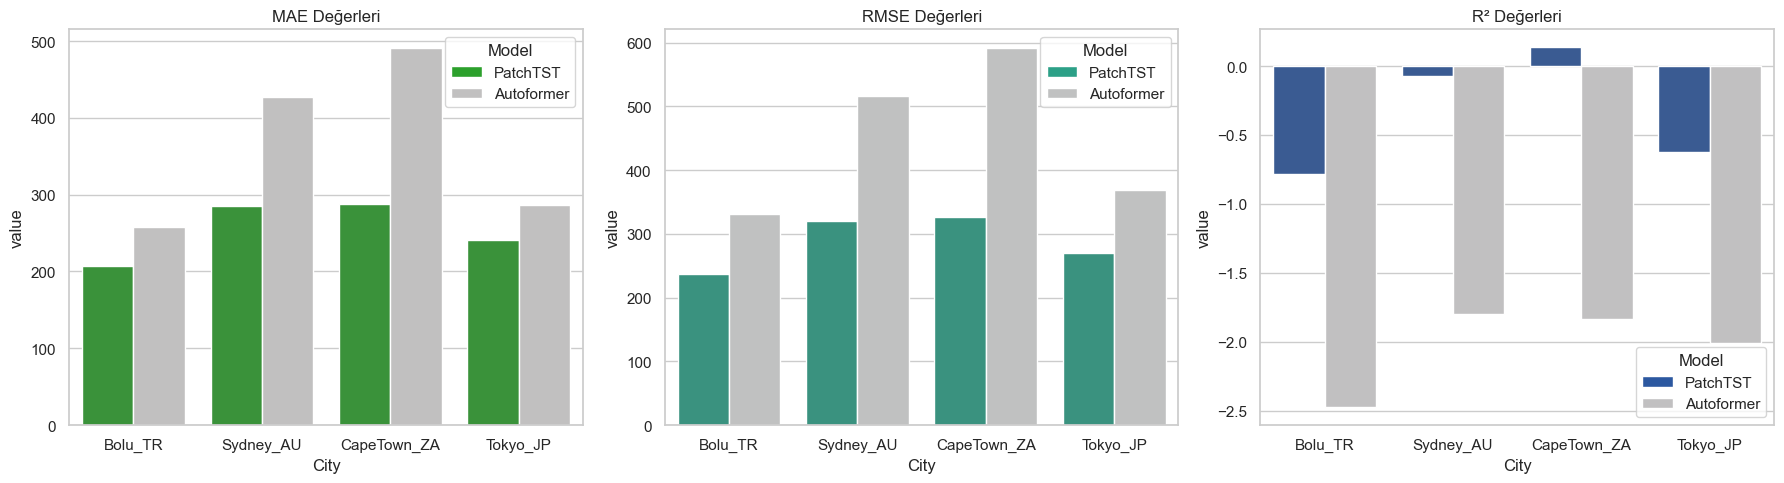

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Veriyi hazırlayalım (Eğer results_df zaten tanımlıysa bu bloğu atlayabilirsin)
# results_df burada kullanılıyor

# Plot ayarları
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Paletler (legend ile tam uyumlu renkler)
pal_mae = {'P_MAE': '#2ca02c', 'A_MAE': "#c1c0c0"}
pal_rmse = {'P_RMSE': "#2ca087", 'A_RMSE': "#c0c1c1"}
pal_r2 = {'P_R2': "#2c58a0", 'A_R2': "#c1c0c1"}

# 1. MAE Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_MAE', 'A_MAE']), 
            x='City', y='value', hue='variable', ax=axes[0], palette=pal_mae)
axes[0].set_title('MAE Değerleri')
handles_mae = [Patch(facecolor=pal_mae['P_MAE']), Patch(facecolor=pal_mae['A_MAE'])]
axes[0].legend(handles_mae, ['PatchTST', 'Autoformer'], title='Model')

# 2. RMSE Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_RMSE', 'A_RMSE']), 
            x='City', y='value', hue='variable', ax=axes[1], palette=pal_rmse)
axes[1].set_title('RMSE Değerleri')
handles_rmse = [Patch(facecolor=pal_rmse['P_RMSE']), Patch(facecolor=pal_rmse['A_RMSE'])]
axes[1].legend(handles_rmse, ['PatchTST', 'Autoformer'], title='Model')

# 3. R2 Plot
sns.barplot(data=results_df.melt(id_vars='City', value_vars=['P_R2', 'A_R2']), 
            x='City', y='value', hue='variable', ax=axes[2], palette=pal_r2)
axes[2].set_title("R² Değerleri")
handles_r2 = [Patch(facecolor=pal_r2['P_R2']), Patch(facecolor=pal_r2['A_R2'])]
axes[2].legend(handles_r2, ['PatchTST', 'Autoformer'], title='Model')

plt.tight_layout()
plt.savefig('../outputs/plots/final_ood_comparison.pdf', bbox_inches='tight')
plt.show()